In [2]:
# event_time ->	Hadisənin baş verdiyi vaxt (UTC ilə)
# event_type ->	Hadisə növü (yalnız purchase — alış)
# product_id ->	Məhsulun ID-si
# category_id	-> Məhsulun kateqoriya ID-si
# category_code	-> Məhsulun kateqoriya adı/kodu (bəzən olmur)
# brand	-> Məhsulun markası (bəzən boş olur)
# price	-> Məhsulun qiyməti
# user_id	-> İstifadəçinin unikal ID-si
# user_session ->	İstifadəçinin session ID-si (hər girişdə dəyişir)

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, chi2_contingency
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download('mkechinov/ecommerce-behavior-data-from-multi-category-store')
print('Dataset faylları:', os.listdir(path))


Using Colab cache for faster access to the 'ecommerce-behavior-data-from-multi-category-store' dataset.
Dataset faylları: ['2019-Nov.csv', '2019-Oct.csv']


In [3]:
import os
print(os.listdir(path))

['2019-Nov.csv', '2019-Oct.csv']


In [4]:
import pandas as pd
df = pd.read_csv(path + "/2019-Oct.csv")

In [5]:
user_counts = df['user_id'].value_counts()
good_users = user_counts[(user_counts >= 5) & (user_counts <= 1000)].index
sample_users = pd.Series(good_users).sample(100000, random_state=42)

In [6]:
df= df[df['user_id'].isin(sample_users)]

In [15]:
df.shape

(2549891, 10)

In [16]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,main_category
21,2019-10-01 00:00:20+00:00,view,4803399,2053013554658804075,electronics.audio.headphone,jbl,33.21,555428858,8a6afed4-77f8-40c9-8e76-e062b28216ce,electronics
49,2019-10-01 00:00:36+00:00,view,1004767,2053013555631882655,electronics.smartphone,samsung,254.82,512558158,9a206ba2-37c7-4354-9d31-37ff3bb297ed,electronics
52,2019-10-01 00:00:42+00:00,view,4803399,2053013554658804075,electronics.audio.headphone,jbl,33.21,555428858,8a6afed4-77f8-40c9-8e76-e062b28216ce,electronics
60,2019-10-01 00:00:46+00:00,view,4100126,2053013561218695907,computers.notebook,sony,326.62,519885473,b70cb218-db90-4011-b582-0bd237109df1,computers
64,2019-10-01 00:00:50+00:00,view,1307135,2053013558920217191,computers.notebook,hp,320.35,542378517,244570b9-ebb4-4d4a-b63a-653225d975d5,computers


## Data cleaning Visualization

In [7]:
df['event_time'] = pd.to_datetime(df['event_time'], utc=True)

In [8]:
# Price describe
print(df['price'].describe().round(2))

count    2579705.00
mean         287.41
std          354.86
min            0.00
25%           65.10
50%          161.84
75%          357.25
max         2574.07
Name: price, dtype: float64


In [9]:
# IQR metodu ilə outlier aşkarlanması
Q1 = df['price'].quantile(0.01)
Q99 = df['price'].quantile(0.99)
df = df[(df['price'] > 0) & (df['price'] <= Q99)]

In [10]:
# Session daxilində forward və backward fill ilə doldurma
df['brand'] = df.groupby('user_session')['brand'].ffill().bfill()
df['category_code'] = df.groupby('user_session')['category_code'].ffill().bfill()
df['brand'] = df['brand'].fillna('unknown')
df['category_code'] = df['category_code'].fillna('unknown')

In [12]:
df['main_category'] = df['category_code'].str.split('.').str[0]

In [14]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,main_category
21,2019-10-01 00:00:20+00:00,view,4803399,2053013554658804075,electronics.audio.headphone,jbl,33.21,555428858,8a6afed4-77f8-40c9-8e76-e062b28216ce,electronics
49,2019-10-01 00:00:36+00:00,view,1004767,2053013555631882655,electronics.smartphone,samsung,254.82,512558158,9a206ba2-37c7-4354-9d31-37ff3bb297ed,electronics
52,2019-10-01 00:00:42+00:00,view,4803399,2053013554658804075,electronics.audio.headphone,jbl,33.21,555428858,8a6afed4-77f8-40c9-8e76-e062b28216ce,electronics
60,2019-10-01 00:00:46+00:00,view,4100126,2053013561218695907,computers.notebook,sony,326.62,519885473,b70cb218-db90-4011-b582-0bd237109df1,computers
64,2019-10-01 00:00:50+00:00,view,1307135,2053013558920217191,computers.notebook,hp,320.35,542378517,244570b9-ebb4-4d4a-b63a-653225d975d5,computers


,count
event_type,
view,2444886
cart,58346
purchase,46659


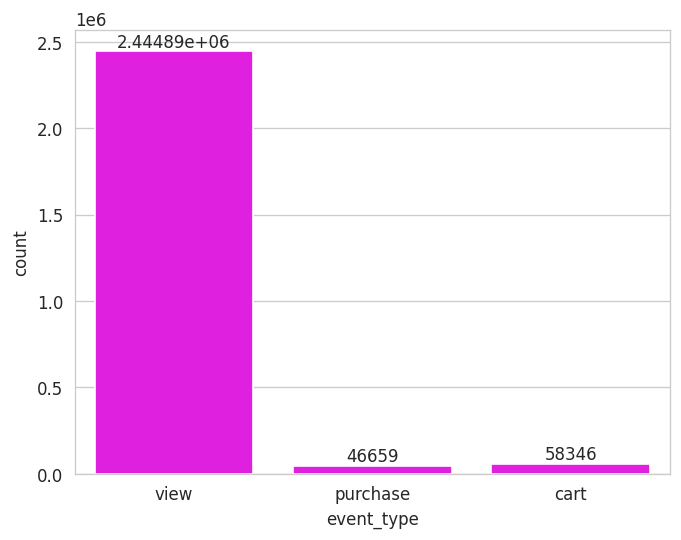

In [18]:
ax = sns.countplot(data=df, x='event_type',color='magenta')
ax.bar_label(ax.containers[0])

df['event_type'].value_counts()

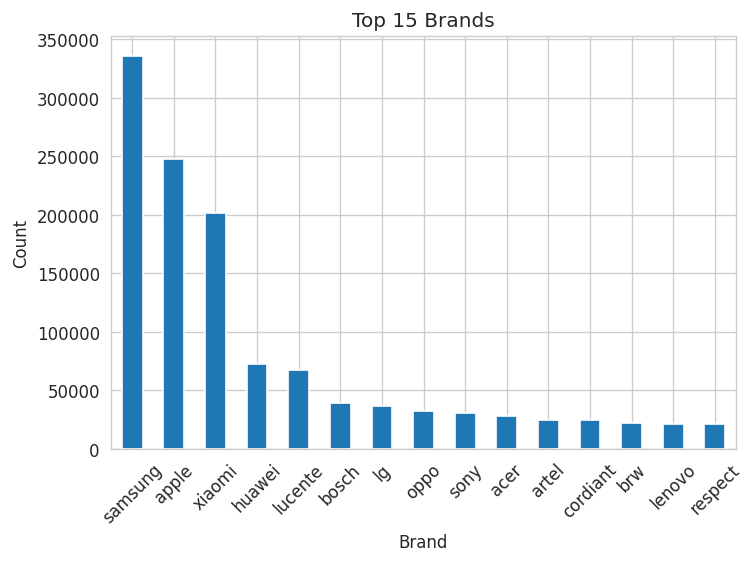

,count
brand,
samsung,335759
apple,247542
xiaomi,201716
huawei,72558
lucente,67359
bosch,39378
lg,36105
oppo,32042
sony,30208


In [25]:
# Top 15 brand
top_brand = df['brand'].value_counts().head(15)

plt.figure()
top_brand.plot(kind='bar')

plt.title('Top 15 Brands')
plt.xlabel('Brand')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()
df['brand'].value_counts().head(15).T

In [27]:
df['main_category'].value_counts()

,count
main_category,
electronics,1341030
appliances,455834
computers,193588
apparel,145489
furniture,134381
auto,99184
construction,74670
kids,52913
accessories,28988


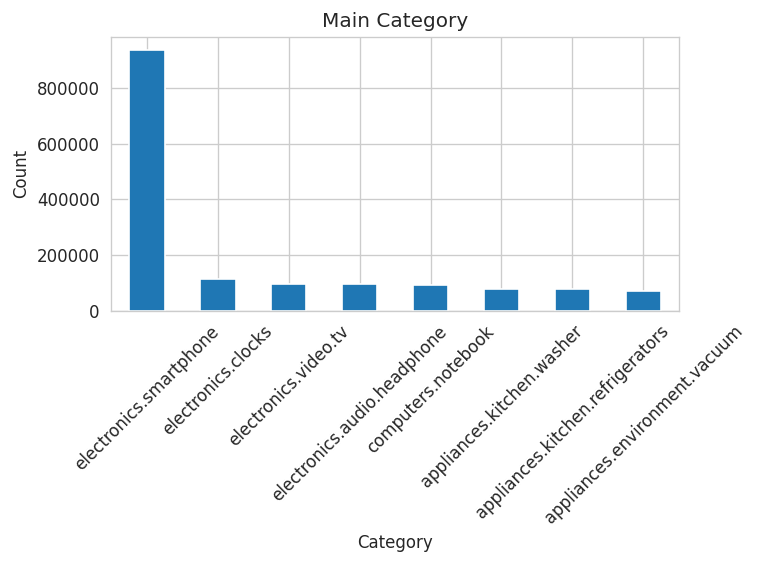

In [33]:
category = df['category_code'].value_counts().head(8)
plt.figure()
category.plot(kind='bar')

plt.title('Main Category')
plt.xlabel('Category')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()


## Making dataset

In [34]:
df['event_time']     = pd.to_datetime(df['event_time'], utc=True)
df['purchase_price'] = df['price'].where(df['event_type'] == 'purchase', 0)
df['is_weekend']     = df['event_time'].dt.dayofweek >= 5

In [35]:
reference_date = df['event_time'].max() + pd.Timedelta(days=1)
purchases = df[df['event_type'] == 'purchase']

In [36]:
# Əsas RFM
rfm = df.groupby('user_id').agg(
    last_event      = ('event_time', 'max'),
    frequency       = ('event_type', lambda x: (x == 'purchase').sum()),
    monetary        = ('purchase_price', 'sum'),
    avg_price       = ('price', 'mean'),
    unique_sessions = ('user_session', 'nunique'),
).reset_index()

In [37]:
rfm['recency'] = (reference_date - rfm['last_event']).dt.days
rfm['session_efficiency'] = (rfm['frequency'] / rfm['unique_sessions'].clip(1)).round(4)

In [142]:
# Kateqoriyalaşırma
cat = df.groupby(['user_id','category_code']).size().reset_index(name='cnt')
cat['share'] = cat['cnt'] / cat.groupby('user_id')['cnt'].transform('sum')
hhi = cat.groupby('user_id')['share'].apply(lambda x: (x**2).sum()).rename('category')
rfm = rfm.merge(hhi, on='user_id', how='left')

In [143]:
hhi.describe()

,category
count,99967.000000
mean,0.566331
std,0.317310
min,0.038943
25%,0.277778
50%,0.506657
75%,0.975072
max,1.000000


In [39]:
# Həftə sonu nisbəti
wknd = df.groupby('user_id')['is_weekend'].mean().rename('weekend_ratio')
rfm  = rfm.merge(wknd, on='user_id', how='left')

rfm = rfm.drop(columns=['last_event','unique_sessions'])

In [41]:
wknd.describe()

,weekend_ratio
count,99967.000000
mean,0.263844
std,0.346832
min,0.000000
25%,0.000000
50%,0.062500
75%,0.465231
max,1.000000


In [46]:
rfm.head()

,user_id,frequency,monetary,avg_price,recency,session_efficiency,category_concentration,weekend_ratio
0,219406386,0,0.0,563.612000,16,0.0,0.680000,0.0
1,265304060,0,0.0,93.130000,8,0.0,0.280000,0.2
2,282977436,0,0.0,343.172917,14,0.0,0.670139,0.0
3,306087674,0,0.0,270.250000,15,0.0,0.440000,0.0
4,306866132,0,0.0,10.010000,10,0.0,0.200000,0.8


In [51]:
features = ['recency','frequency','monetary','avg_price','session_efficiency','category_concentration']
labels   = ['Recency','Frequency','Monetary','Orta Qiymət','Session Eff','Kateqorik cəmlənmə']

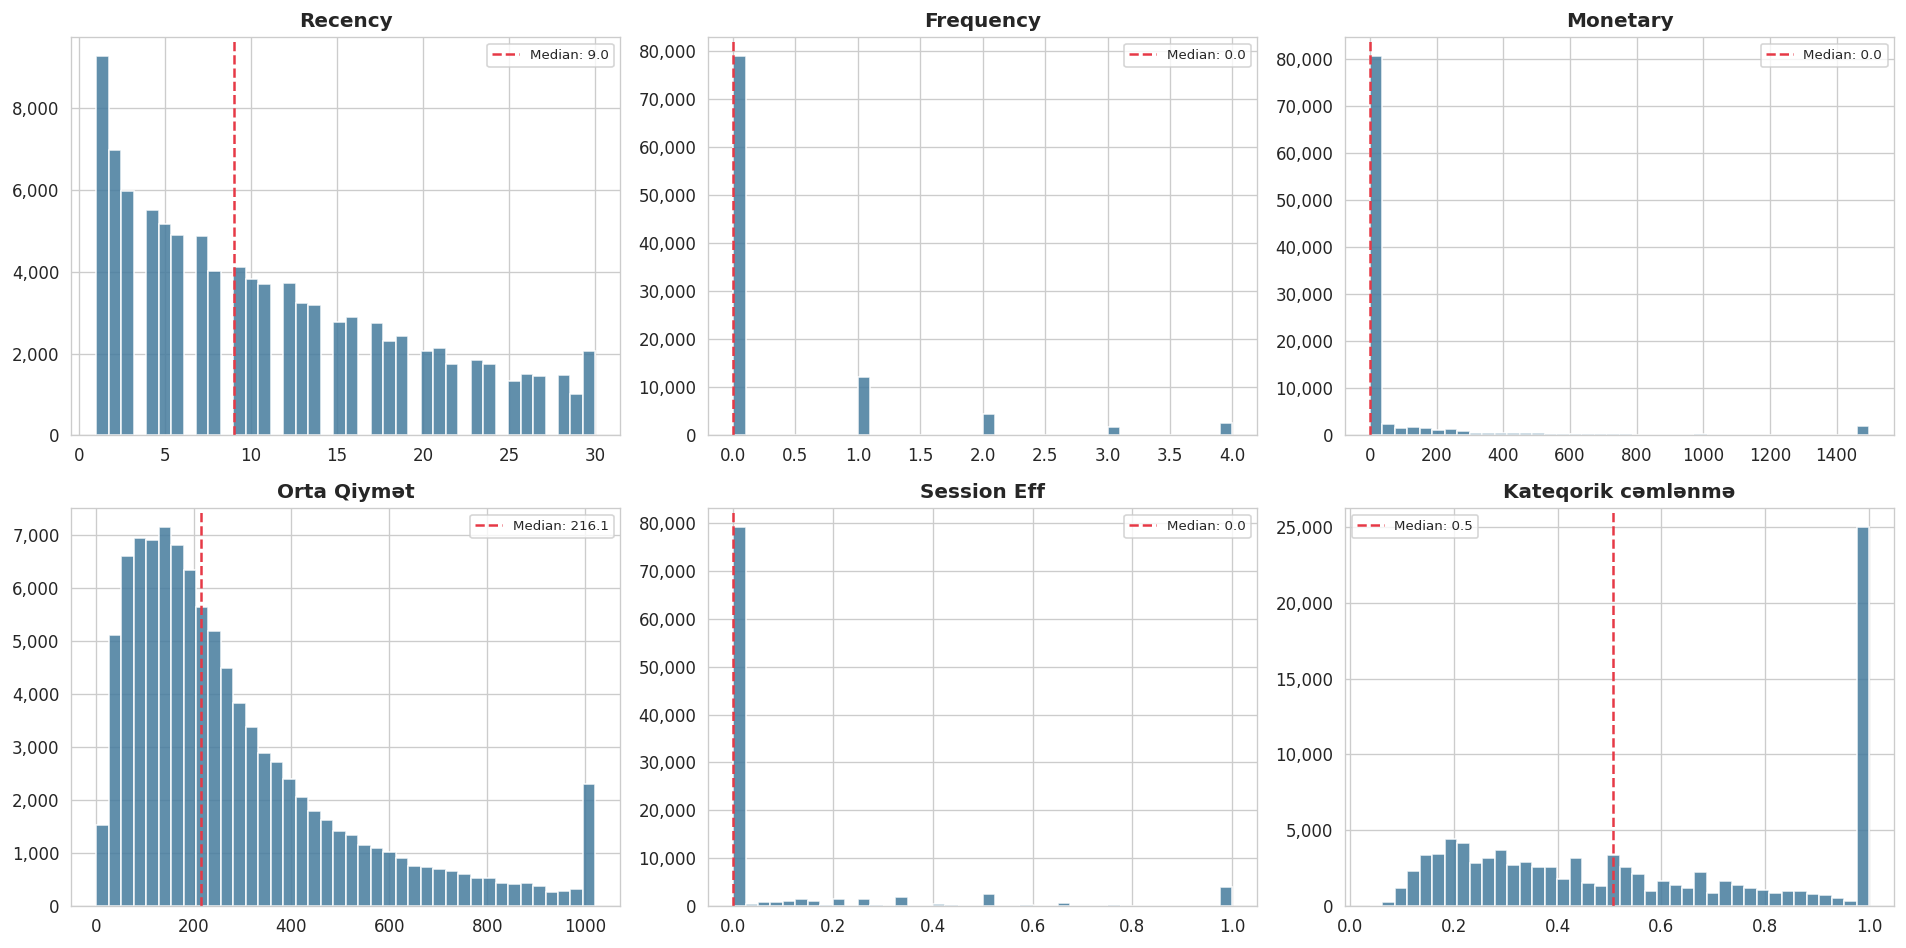

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col, lbl in zip(axes.flatten(), features, labels):
    data = rfm[col].clip(upper=rfm[col].quantile(0.98))
    ax.hist(data, bins=40, color='#457B9D', edgecolor='white', alpha=0.85)
    ax.axvline(rfm[col].median(), color='#E63946', linestyle='--', linewidth=1.5,
               label=f'Median: {rfm[col].median():.1f}')
    ax.set_title(lbl, fontweight='bold'); ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout();

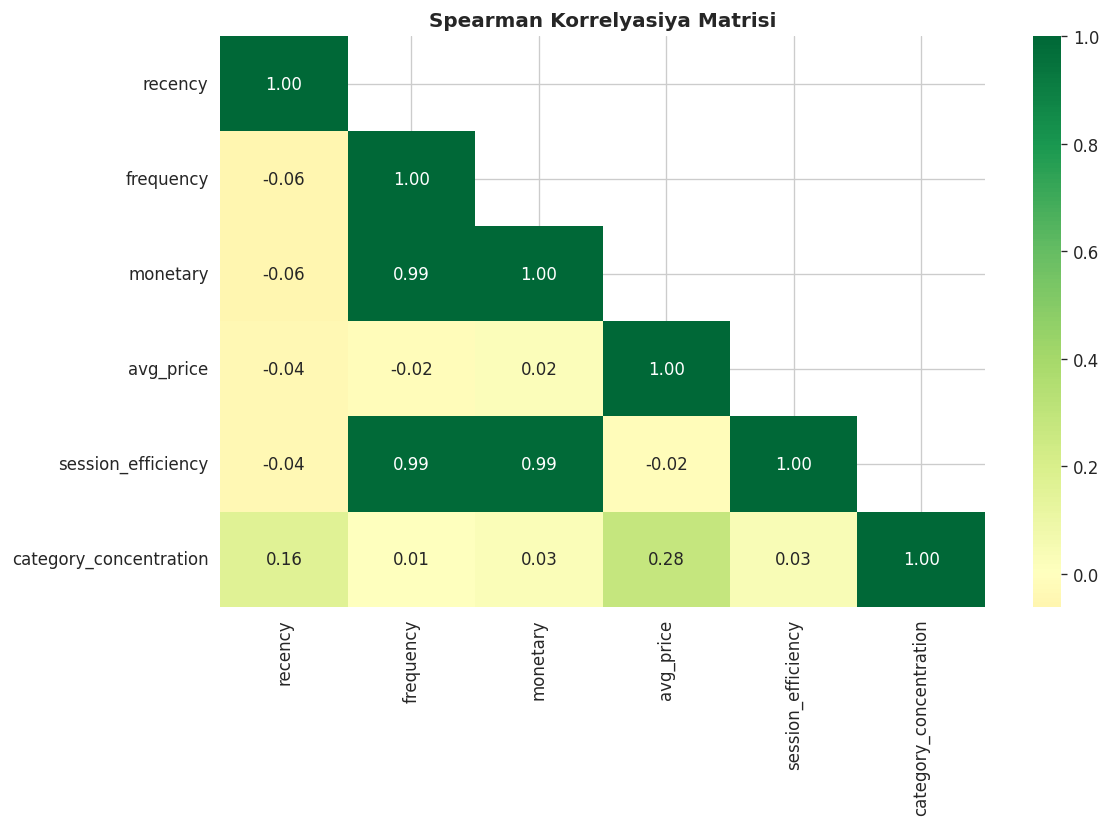

In [53]:
# Korrelyasiya
corr = rfm[features].corr(method='spearman')
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr), k=1),
            annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Spearman Korrelyasiya Matrisi', fontweight='bold')
plt.tight_layout();

In [54]:
# Scaling
X = rfm[features].copy()
X['log_frequency'] = np.log1p(X.pop('frequency'))
X['log_monetary']  = np.log1p(X.pop('monetary'))
X_scaled = RobustScaler().fit_transform(X)

In [55]:
X_scaled

array([[ 0.53846154,  1.35489726,  0.        ,  0.24859396,  0.        ,
         0.        ],
       [-0.07692308, -0.47936622,  0.        , -0.32505177,  0.        ,
         0.        ],
       [ 0.38461538,  0.49547361,  0.        ,  0.234452  ,  0.        ,
         0.        ],
       ...,
       [-0.61538462, -0.63489958,  0.        , -0.31250327,  0.        ,
         0.        ],
       [-0.61538462,  0.29675132,  0.        ,  0.04378821,  0.        ,
         0.        ],
       [-0.61538462, -0.62363724,  0.        , -0.32823869,  0.        ,
         0.        ]])

In [81]:
k_range = range(2, 10)

inertias = []
silhouettes = []

sample_idx = np.random.choice(len(X_scaled), min(3000, len(X_scaled)), replace=False)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled[sample_idx], labels[sample_idx]))

best_k = list(k_range)[np.argmax(silhouettes)]

In [83]:
inertias

[197737.41826695215,
 147846.02473184458,
 117695.7151113041,
 97792.07068723596,
 87755.86547909243,
 78072.21945379373,
 72427.85888917184,
 66827.45249266464]

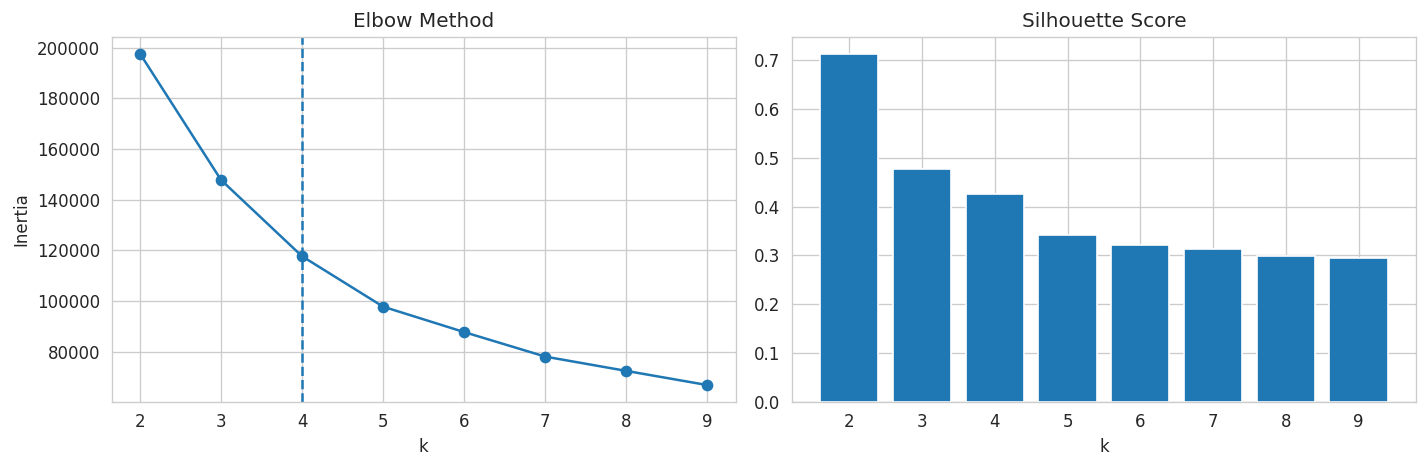

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Elbow
ax[0].plot(k_range, inertias, marker='o')
ax[0].axvline(4, linestyle='--')
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

# Silhouette
ax[1].bar(k_range, silhouettes)
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("k")

plt.tight_layout()
plt.show()

In [87]:
model1 = KMeans(n_clusters=4, random_state=42, n_init=20)

rfm['cluster'] = model1.fit_predict(X_scaled)
print("Silhouette score:",silhouette_score(X_scaled, rfm['cluster']))

Silhouette score: 0.43142022787609385


In [92]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
exp = pca.explained_variance_ratio_

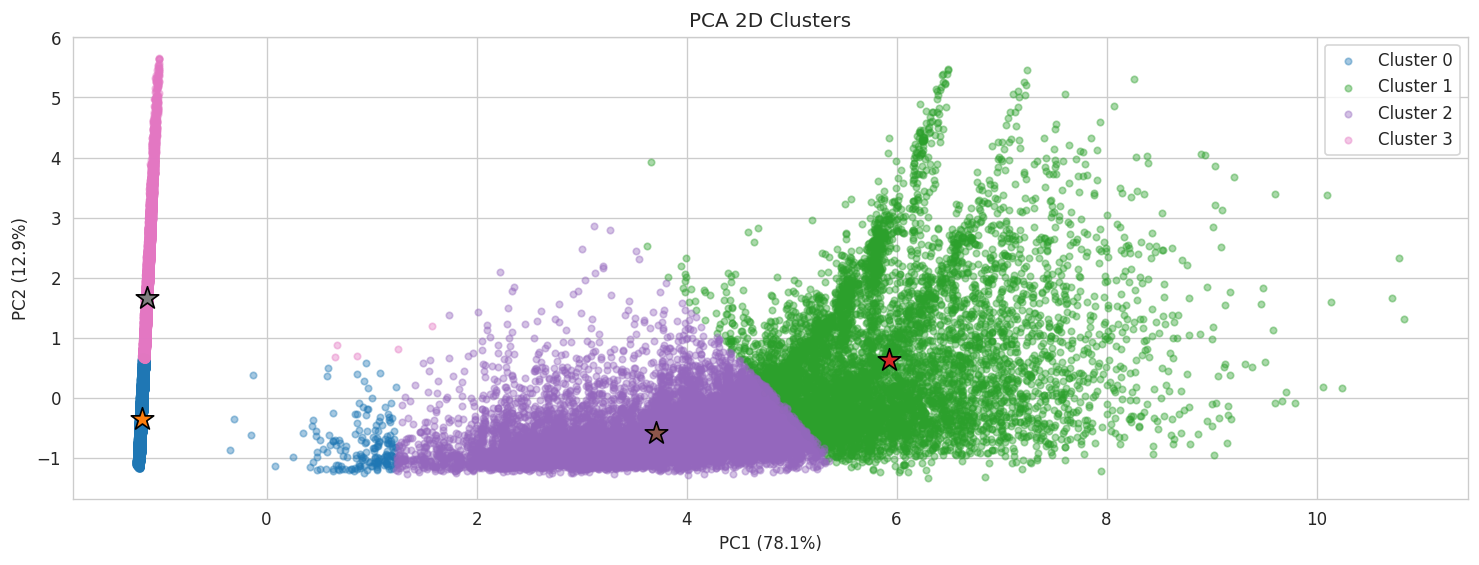

In [97]:
fig, (ax1) = plt.subplots(figsize=(15, 5))

clusters = sorted(rfm['cluster'].unique())

for cl in clusters:
    mask = rfm['cluster'] == cl

    # points
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {cl}', alpha=0.4, s=15)

    # cluster center
    ax1.scatter(X_pca[mask, 0].mean(),
                X_pca[mask, 1].mean(),
                s=200, marker='*', edgecolors='k')

ax1.set_title("PCA 2D Clusters")
ax1.set_xlabel(f"PC1 ({exp[0]*100:.1f}%)")
ax1.legend()

## Category

In [147]:
med = rfm.groupby('cluster')[['recency', 'frequency', 'monetary','avg_price', 'session_efficiency']].median()
global_med = rfm[['recency', 'frequency', 'monetary','avg_price', 'session_efficiency']].median()

In [157]:
med

,recency,frequency,monetary,avg_price,session_efficiency
cluster,,,,,
0,9.0,0.0,0.000,178.042857,0.00
1,8.0,2.0,915.640,409.457292,0.50
2,8.0,1.0,141.285,149.693073,0.25
3,10.0,0.0,0.000,635.963921,0.00


In [148]:
def auto_label(row):
    rec = row['recency'] < global_med['recency']
    freq = row['frequency'] > global_med['frequency']
    mon = row['monetary'] > global_med['monetary']

    if rec and freq and mon:
        return 'VIP'
    elif rec and freq:
        return 'Active Buyers'
    elif not rec and not freq and mon:
        return 'Premium Occasional'
    elif not rec and not freq:
        return 'Churn Risk'
    elif rec and not freq:
        return 'New Customers'
    else:
        return 'Regular'

In [149]:
'''
Bu funksiya hər müştərini 3 göstəriciyə görə qiymətləndirir
son alışdan keçən vaxt (recency), alış sayı (frequency) və
xərclədiyi pul (monetary). Sonra hər bir müştərinin bu
dəyərlərini ümumi medianla müqayisə edir.

Əgər müştəri həm aktivdirsə, tez-tez alış edirsə və çox
pul xərcləyirsə, onu VIP kimi tanıyır. Aktivdir və tez-tez alır,
amma az xərcləyirsə Active Buyers olur. Uzun müddətdir alış etməyən,
az aktiv və aşağı xərcli müştərilər Churn Risk sayılır. Yeni gələn,
amma hələ az alış edənlər New Customers olur. Qalan bütün müştərilər
isə Regular (orta) kimi qruplaşdırılır.
'''

'\nBu funksiya hər müştərini 3 göstəriciyə görə qiymətləndirir \nson alışdan keçən vaxt (recency), alış sayı (frequency) və \nxərclədiyi pul (monetary). Sonra hər bir müştərinin bu \ndəyərlərini ümumi medianla müqayisə edir.\n\nƏgər müştəri həm aktivdirsə, tez-tez alış edirsə və çox \npul xərcləyirsə, onu VIP kimi tanıyır. Aktivdir və tez-tez alır, \namma az xərcləyirsə Active Buyers olur. Uzun müddətdir alış etməyən, \naz aktiv və aşağı xərcli müştərilər Churn Risk sayılır. Yeni gələn, \namma hələ az alış edənlər New Customers olur. Qalan bütün müştərilər \nisə Regular (orta) kimi qruplaşdırılır.\n'

In [150]:
cluster_labels = {}

for cl in med.index:
    cluster_labels[cl] = auto_label(med.loc[cl])

rfm['segment_name'] = rfm['cluster'].map(cluster_labels)

In [151]:
# 10 sample ilə nümunə
rfm.sample(10)[['user_id', 'cluster', 'segment_name']]

,user_id,cluster,segment_name
75452,555360741,2,VIP
92799,562256692,0,Churn Risk
98396,565127847,0,Churn Risk
70481,552050268,0,Churn Risk
96962,564313949,0,Churn Risk
67689,549930723,3,Churn Risk
87687,560142645,0,Churn Risk
675,512387515,3,Churn Risk
75356,555313888,0,Churn Risk
66197,548795112,3,Churn Risk


In [153]:
profile_features = ['recency', 'frequency', 'monetary','avg_price', 'category_concentration']
profile = rfm.groupby('cluster')[profile_features].agg(['mean', 'median', 'std']).round(2)
profile_median = rfm.groupby('cluster')[profile_features].median().round(2)

In [154]:
profile_median['müştəri_sayı'] = rfm.groupby('cluster').size()
profile_median['faiz'] = (profile_median['müştəri_sayı'] / len(rfm) * 100)

print(profile_median)

         recency  frequency  monetary  avg_price  category_concentration  \
cluster                                                                    
0            9.0        0.0      0.00     178.04                    0.44   
1            8.0        2.0    915.64     409.46                    0.73   
2            8.0        1.0    141.28     149.69                    0.45   
3           10.0        0.0      0.00     635.96                    0.80   

         müştəri_sayı       faiz  
cluster                           
0               63967  63.988116  
1                7396   7.398441  
2               13336  13.340402  
3               15268  15.273040  


## DBSCAN

In [158]:
db = DBSCAN(eps=0.5, min_samples=10)
labels = db.fit_predict(X_scaled)

rfm['dbscan_cluster'] = labels


In [159]:
rfm['dbscan_cluster'].value_counts()

,count
dbscan_cluster,
0,79048
1,19380
-1,1248
2,193
4,26
3,22
6,18
5,16
7,10


In [ ]:
plt.figure(figsize=(12,5))

dendrogram = sch.dendrogram(
    sch.linkage(X_scaled, method='ward')
)

plt.title("RFM Dendrogram")
plt.show()